# LLMs guessing algorithms to process images
In this notebook we will use a LLM to guess an algorithm that could be used to process an image.

We do this 25 times and draw a wordcloud from the responses.

In [1]:
import openai
import os
import wordcloud
import matplotlib.pyplot as plt

In [2]:
def prompt_ollama(prompt:str, model="gemma3:12b"):
    """A prompt helper function that sends a prompt to 
    ollama and returns only the text response."""
    # setup connection to the LLM server
    client = openai.OpenAI(
        base_url = "http://localhost:11434/v1",
        api_key = "none" # not required by ollama
    )
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    
    # extract answer
    return response.choices[0].message.content

In [3]:
responses = []
for _ in range(25):
    responses.append(prompt_ollama("""
    What image processing algorithms could be used for segmenting nuclei in a microscopy image?
    Answer the algorithm name only. No explanations.
    """))
responses

['*   Thresholding\n*   Clustering (K-means, Gaussian Mixture Models)\n*   Watershed\n*   Morphological Operations\n*   Region Growing\n*   Contour Detection\n*   Active Contours (Snakes)\n*   Level Set Methods\n*   Hough Transform\n*   Marker-Controlled Watershed\n*   Distance Transform\n*   Deep Learning (U-Net, Mask R-CNN)\n*   CellProfiler\n*   STARSpot\n*   Filamentary Structure Analysis (FSA)\n',
 '*   Thresholding\n*   Edge Detection\n*   Watershed\n*   Region Growing\n*   Marker-controlled Watershed\n*   Active Contours\n*   Level Sets\n*   Hough Transform\n*   K-means Clustering\n*   Mean Shift\n*   Graph Cuts\n*   U-Net\n*   Mask R-CNN\n*   DeepLab\n',
 'Thresholding\nWatershed\nMorphological Operations\nRegion Growing\nContour Detection\nActive Contours\nDeformable Models\nDistance Transform\nMarker-Controlled Watershed\nMachine Learning (e.g., U-Net, Mask R-CNN)\nClustering (e.g., K-means, Gaussian Mixture Models)\nHough Transform\nEdge Detection\nConnected Component Analys

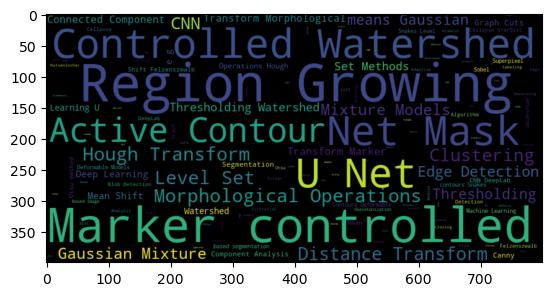

In [4]:
text = "\n".join(responses)

# Generate word cloud
w = wordcloud.WordCloud(width=800, height=400, colormap='viridis').generate(text)

# Display the word cloud
plt.imshow(w, interpolation='bilinear')

## Exercise
* Try a different language model and/or LLM service provider. Does the response become more clear?
* Ask the LLM which Python libraries to use for the task. Check the responses carefully. Do all the libraries exist?